# Домашнее задание 2 (10 баллов).

*Все задания ниже имеют равный вес*

Код для импорта мы написали за вас (не благодарите, нам не трудно). Дальше код будете писать вы.

[Тут](https://habr.com/ru/companies/ruvds/articles/494720/) шпора по pandas. За основу домашнего задания взят ноутбук [отсюда](https://rutube.ru/video/f884aa6ed5f94120b7304506042fe5bb/) (не подглядывайте!).

Султанбекова Орнелла ИАД-9

In [ ]:
!pip install pandas

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 5.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.9 MB 7.5 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.9 MB 8.4 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 8.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.9 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 8.3 MB/s  0:00:01
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np

#### Описание данных

Автор д/з - плохой человек, который не стал переводить описание с мотивировкой, что весь DS на английском. Так что описание полей будет на английском:

1. Account ID
- Description: A unique identifier for each social media account in the dataset.
- Type: Integer
- Example: 1, 2, 3, …
2. Username
- Description: The username or handle of the social media account.
- Type: String
- Example: john_doe, tech_guru_22, fitness_freak
3. Platform
- Description: The social media platform the account is using (Instagram, Twitter, Facebook, TikTok, LinkedIn).
- Type: Categorical (String)
- Example: Instagram, Twitter, Facebook, TikTok, LinkedIn
4. Follower Count
- Description: The total number of followers the account has.
- Type: Integer
- Example: 1500, 245000, 78000
5. Posts Per Week
- Description: The average number of posts the account creates per week.
- Type: Integer
- Example: 3, 5, 7
6. Engagement Rate
- Description: The percentage of interactions (likes, comments, shares) relative to the follower count. This is a measure of how engaging the content is.
- Type: Float
- Range: 0.01 to 0.15
- Example: 0.045 (4.5% engagement rate)
7. Ad Spend (USD)
- Description: The monthly amount spent on advertising or promoting posts.
- Type: Float
- Example: 150.75, 850.00, 300.50
8. Conversion Rate
- Description: The percentage of users who take a desired action (e.g., clicking a link, signing up, etc.) after interacting with an ad.
- Type: Float
- Range: 0.01 to 0.05 (1% to 5% conversion rate)
- Example: 0.025 (2.5% conversion rate)
9. Campaign Reach
- Description: The total number of unique users reached by the user’s campaigns in a given month.
- Type: Integer
- Example: 5000, 20000, 15000

#### Задание 0

Подгрузите данные. Да-да, за чтение таблицы баллов не будет))

**Hint**: [pd.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)

In [ ]:
df = pd.read_csv("data.csv", index_col="Account ID")

In [ ]:
df

,Username,Platform,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach
Account ID,,,,,,,,
1,harrislisa,TikTok,54217,3,0.0986,538.10,0.0490,1308
2,rhicks,LinkedIn,987518,5,0.0834,479.24,0.0174,13302
3,qthomas,Facebook,218870,3,0.1020,150.36,0.0318,11043
4,carlosholt,Instagram,207432,6,0.0834,932.62,0.0400,12074
5,parsonsashley,Facebook,350204,2,0.0642,504.44,0.0463,14083
...,...,...,...,...,...,...,...,...
9996,sbyrd,TikTok,388169,6,0.0642,362.91,0.0108,45091
9997,jacksongerald,TikTok,150775,1,0.0642,177.92,0.0262,33084
9998,eryan,Twitter,427451,5,0.0834,432.65,0.0402,12484


#### Задание 1

Колонка `Platform` содержит название различных платформ. Давайте представим, что в них есть некоторое отношение порядка. Закодируйте каждую платформу целым числом (от 0 до N) и положите этот "код" в новую колонку `Platform_Code`. Теперь вычислите корреляцию Спирмена между всеми парами колонок в датасете (результатом будет таблица корреляций). В качестве ответа выведите значение корреляции `Platform_Code` с `Engagement Rate`. Можете после вывода числа еще коротко написать, что оно означает (нет, это не оценивается).

**Hint**: [pd.factorize](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.factorize.html), [pd.DataFrame.select_dtypes](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html), [pd.DataFrame.corr](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html).

In [ ]:
platforms = df['Platform']
codes, uniques = pd.factorize(platforms)
df['Platform_Code'] = codes

numeric_df = df.select_dtypes(include=np.number)
corr_matix = numeric_df.corr()
result = corr_matix.loc['Platform_Code', 'Engagement Rate']
print(result) # показывает, что платформа особо не влияет на уровень вовлеченности

0.03470195165241881


#### Задание 2

Теперь посмотрите на столбец `Follower Count`. В нем какие-то числа. Иногда бывает полезно провести дискретизацию такого признака. Разбейте все значения в столбце на 4 группы: "Low", "Medium", "High", "Very High". Каждая группа включает в себя новые 25% данных. То есть, Low включает в себя 25% самых маленьких значений признака и так далее. Положите значения "Low", "Medium", "High" или "Very High" для каждого сэмпла датасета в новую колонку `Follower_Bin`. Теперь посчитайте среднее значение `Engagement Rate` для каждой категории из `Follower_Bin`. В качестве ответа выведите значение для категории "High".

**Hint**: [pd.qcut](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html), [pd.groupby](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html), [pd.DataFrame.mean](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.mean.html)

In [ ]:
df['Follower_Bin'] = pd.qcut(df['Follower Count'], 4, labels=['Low', 'Medium', 'High', 'Very High'])
engagement_by_bin = df.groupby('Follower_Bin')['Engagement Rate'].mean()
result = engagement_by_bin['High']
print(result)

0.08655032


#### Задание 3

Иногда бывает полезно превратить широкую таблицу в длинную (например, для визуализаций сразу нескольких признаков на одной картинке). Да, звучит странно, но именно этим вы сейчас и займетесь. Сделайте новый датафрейм `melted_df`, в который вы поместите каждый сэмпл датасета 6 раз: по одному разу на значение из 'Follower Count', 'Posts Per Week', 'Ad Spend (USD)', 'Conversion Rate', 'Engagement Rate' и 'Campaign Reach'. То есть, вы берете сэмпл из датасета (строку) и превращаете ее в 6 отдельных строк. Каждая отдельная строка в столбце `Metric` имеет имя из предложенного списка 5 признаков, а в столбце `Value` - значение данного сэмпла по этому признаку. Значение `Platform` повторяется в этих 6 строках.

Иначе говоря,

```json
{
    "Account ID": 1,
    "Username": "harrislisa",
    "Platform": "TikTok",
    "Follower Count": 54217,
    "Posts Per Week": 3,
    "Engagement Rate": 0.0986,
    "Ad Spend (USD)": 538.1,
    "Conversion Rate": 0.049,
    "Campaign Reach": 1308,
    "Platform_Code": 0,
    "Follower_Bin": "Low"
}
```

превращается в

```json
{
    "Platform": "TikTok",
    "Metric": "Follower Count",
    "Value": 54217,
},
{
    "Platform": "TikTok",
    "Metric": "Posts Per Week",
    "Value": 3,
}, ...
```

Для каждого уникальной пары значений (`Platform`, `Metric`) посчитайте моду среди всех значений `Value` для этой пары, результат сделайте списком и оставьте только наибольшее. В качестве ответа выведите сумму полученных мод (сумму всех значений в столбце `Value` уже после вычисления мод). Иначе говоря, выведите сумму всех мод значений для всех уникальных пар (`Platform`, `Metric`).

**Hint**: [pd.melt](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.melt.html), [pd.DataFrame.mode](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.mode.html), [pd.DataFrameGroupBy.agg](https://pandas.pydata.org/docs/dev/reference/api/pandas.core.groupby.DataFrameGroupBy.agg.html)

In [ ]:
melt_vars = ['Follower Count', 'Posts Per Week', 'Ad Spend (USD)', 'Conversion Rate', 'Engagement Rate', 'Campaign Reach']
melt_df = df.melt(id_vars=['Platform'], value_vars=melt_vars, var_name='Metric', value_name='Value')
mode_val = melt_df.groupby(['Platform', 'Metric'])['Value'].agg(lambda x: x.mode().max() if not x.empty else None)
result = mode_val.sum()
print(result)

3100285.4716


#### Задание 4

А теперь хочется посмотреть на самые популярные аккаунты на разных платформах. Для каждой платформы отсортируйте датафрейм по убыванию количества подписчиков (`Follower Count`) - да, без циклов, сразу для всех платформ сделать сортировку, а затем оставьте только первые три записи для каждой платформы - это и будут три самых популярных аккаунта для каждой платформы. В качестве ответа выведите саму таблицу и минимальное значение `Follower Count` в ней.

**Hint**: к *groupby* можно применять функции - это эквивалентно применению функции к каждой "группе" внутри groupby-объекта. Читайте [про применение apply к датафрейму после groupby](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html#flexible-apply).

In [ ]:
top_acc = df.groupby('Platform').apply(lambda x: x.sort_values('Follower Count', ascending=False).head(3))
print(top_acc)
result = top_acc['Follower Count'].min()
print(result)

                             Username  Follower Count  Posts Per Week  \
Platform  Account ID                                                    
Facebook  2404                 eric65          999982               6   
          7351           patricknoble          997915               3   
          1690            chavezjason          997512               7   
Instagram 8686        alexandersamuel          999726               3   
          3966               lrodgers          999351               1   
          2190                 jbrown          997844               5   
LinkedIn  3040                toneill          999055               4   
          6360          andrewgregory          998968               7   
          2160           ashleycooper          998925               6   
TikTok    5839           edwardthomas          999739               7   
          4235          andradewesley          999234               5   
          2576           williamwyatt          9986

#### Задание 5

Хочется посчитать какую-то метрику. Мы хотим посмотреть, на отношение разности суммы подписчиков аккаунтов с высокой и низкой конверсией к суммарному охвату рекламы на каждой платформе. То есть, мы делим аккаунты на две группы: высокая и низка конверсия. Затем мы смотрим на то, на сколько сильно влияние аккаунтов с высокой конверсией по сравнению с аккаунтами с низкой конверсией.

Давайте определим *Conversion Influence* следущим образом:

$$Conversion Influence = \frac{Total Follower\ Count (High) - Total Follower\ Count (Low)}{Total Campaign Reach (High)+Total Campaign Reach (Low)}$$

Считать эту метрику мы будет для каждой `Platform`. В этой формуле High - это значения всех сэмплов датасета, в которых `Conversion Rate` больше медианы, а `Low` - не более медианы. `Total Feature` - это суммарное количество значений `Feature` либо по `High` сэмплам, либо по `Low`.

Чтобы постоянно не пересчитывать, где High. где Low, сделайте новую колонку в датасете `Conversion_Category`. Положите в нее для каждой строки либо High, либо Low.

Выведите платформу с самым большим `Conversion Influence`.

**Hint**: данное задание не про *groupby*, а скорее про [pd.pivot_table](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html). Сделайте сводную таблицу, по которой уже можно посчитать суммы, а затем подставить их в формулы.

In [ ]:
mediana = df['Conversion Rate'].median()
df['Conversion_Category'] = df['Conversion Rate'].apply(lambda x: 'High' if x > mediana else 'Low')
table = pd.pivot_table(df, values=['Follower Count', 'Campaign Reach'], index='Platform', columns='Conversion_Category', aggfunc='sum', fill_value=0)
table['Conversion_Influence'] = (table[('Follower Count', 'High')] - table[('Follower Count', 'Low')]) / (table[('Campaign Reach', 'High')] + table[('Campaign Reach', 'Low')])
result_platform = table['Conversion_Influence'].idxmax()
print(result_platform)

Twitter


#### Задание 6

Мы знаем, что вам понравилось считать метрики по формуле. Давайте закрепим этот успех. Теперь для каждой платформы посчитаем, на сколько эффективна реклама в разрезе трех последовательных записей в датасете.

Для каждой платформы отсортируйте записи в порядке убывания `Posts Per Week`. Будто бы аккаунты, которые постят чаще, используют более "активные" стратегии по рекламе. Теперь посчитайте *скользущие суммы с окном 3* по `Campaign Reach` и `Ad Spend (USD)`. Скользящая сумма с окном N - это вы идете по массиву, берете все последовательные тройки записей и суммируете их. Для первых двух записей троек не найдется. Для них скользящее среднее - NaN, что нам не помешает.

Теперь для каждого окна посчитайте

$$Rolling Efficiency Ratio = \frac{Rolling Sum of Campaign Reach}{Rolling Sum of Ad Spend}$$

По сути, для каждого окна вы посчитаете сколько пользователе привлеклось за один доллар, потреченный на рекламу, в данном окне. Понятно, что значений будет столько, сколько окон. Нам интересно максимально значение такой эффективности для каждой платформы.

В качестве ответа выведите название платформы с наибольшей максимальной эффективность и наименьшей (два названия, не одно, не три, ровно два).

**Hint**: окна можно делать через [pd.DataFrame.rolling](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html).

In [ ]:
df_sort = df.sort_values(['Platform', 'Posts Per Week'], ascending=False)
rolling = df_sort.groupby('Platform')[['Campaign Reach', 'Ad Spend (USD)']].rolling(3).sum().reset_index().dropna()
rolling['Efficiency'] = rolling['Campaign Reach'] / rolling['Ad Spend (USD)']
max_enfunce = rolling.groupby('Platform')['Efficiency'].max()
max_platform, min_platform = max_enfunce.idxmax(), max_enfunce.idxmin()
print(max_platform, min_platform)

Facebook TikTok


#### Задание 7

Это еще не все прекрасные функции pandas, которые мы хотим вам показать. Теперь вы посчитаете, сколько аккаунтов на каждой платформе одновременно лучшие по `Engagement Rate` и `Conversion Rate`.

Сделайте два отдельных суб-сета. В одном оставьте для каждой платфмормы один топовый аккаунт по `Engagement Rate`, в другом - по `Conversion Rate`. Соедините эти два подмножества по столбцу `Platform` так, что в одно строке есть описание сразу двух аккаунтов-лидеров. Теперь посмотрите равны ли имена аккаунтов в одной строке. Выведите количество строк, в которых названия аккаунтов совпадают.

In [ ]:
top_engagement = df.loc[df.groupby('Platform')['Engagement Rate'].idxmax()][['Platform', 'Username', 'Engagement Rate']]
top_conversion = df.loc[df.groupby('Platform')['Conversion Rate'].idxmax()][['Platform', 'Username', 'Conversion Rate']]
table = pd.merge(top_engagement, top_conversion, on='Platform')
result = (table['Username_x'] == table['Username_y']).sum()
print(result)

0


#### Задание 8

Давайте теперь что-то попроще сделаем. Например, посчитаем отношение суммарного количества подписчиков на аккаунтах с высокой конверсией к такой же сумме в аккаунтах с низкой конверсией (очевидно, для каждой платформы). По сути, мы просто хотим получить число, которое характеризует, на сколько сильно аккаунты с высокой конверсией "доминируют" над аккаунтами с низкой конверсией в плане количества подписчиков.

Высокой конверсией будем считать конверсию больше средней. Остальное - низкая. Посчитайте суммы подписчиков для каждой платформы, поделите одно на другое и выведите разницу между самым большим значением и самым маленьким, а также платформы, которые соотвутствуют этим значениям.

Используйте магическую команду `%%time`, чтобы замерить, сколько времени ушло на исполнение вашего pandas-скрипта.

In [ ]:
%%time
avg_conversion = df['Conversion Rate'].mean()
df['Conversion_Category'] = np.where(df['Conversion Rate'] > avg_conversion, 'High', 'Low')
follower_sums = df.groupby(['Platform', 'Conversion_Category'])['Follower Count'].sum().unstack(fill_value=0)
follower_sums['Ratio'] = follower_sums['High'] / follower_sums['Low']
diff = follower_sums['Ratio'].max() - follower_sums['Ratio'].min()
platform_max = follower_sums['Ratio'].idxmax()
platform_min = follower_sums['Ratio'].idxmin()

print('Разница =', diff)
print('Платформа с max отношением:', platform_max)
print('Платформа с min отношением:', platform_min)

Разница = 0.17688741338715763
Платформа с max отношением: Twitter
Платформа с min отношением: Instagram
CPU times: total: 0 ns
Wall time: 4.88 ms


#### Задание 9

А теперь решите задание 8 чисто питоном. Никаких функций и методов pandas. Только питоновские циклы. Замерьте время выполнения кода. Наконец, сравните время в задании 8 и 9. Напишите ниже, кто же победил: чистый python и pandas?

**Hint**: Чтобы итерироваться по датафрейму, можно из него сделать генератор через [pd.DataFrame.iterrows](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iterrows.html) или [pd.DataFrame.itertuples](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.itertuples.html#pandas.DataFrame.itertuples). К слову, это не все способы итерироваться по датафрейму.

In [ ]:
%%time
avg_conversion = df['Conversion Rate'].mean()
sums = {}
for index, row in df.iterrows():
    platform = row['Platform']
    follower_count = row['Follower Count']
    category = 'High' if row['Conversion Rate'] > avg_conversion else 'Low'
    if platform not in sums:
        sums[platform] = {'High': 0, 'Low': 0}
    sums[platform][category] += follower_count

ratios = {}
for platform, values in sums.items():
    ratios[platform] = values['High'] / values['Low']

diff = max(ratios.values()) - min(ratios.values())
platform_max = [p for p, r in ratios.items() if r == max_ratio][0]
platform_min = [p for p, r in ratios.items() if r == min_ratio][0]
print('Разница =', diff)
print('Платформа с max отношением:', platform_max)
print('Платформа с min отношением:', platform_min)

Разница = 0.17688741338715763
Платформа с max отношением: Twitter
Платформа с min отношением: Instagram
CPU times: total: 188 ms
Wall time: 151 ms


**А победителем является**: pandas. Время выполнения быстрее почти в 31 раз (151 / 4.88 = 30.94)

#### Задание 10

Крайне серьезное задание. Отнеситесь к нему соответствующе. В ячейке ниже напишите ваш любимый анекдот или мем (только без баянов, окей?). Можно плохие. Помните, это задание на полный балл. Проверяющий работу ассистент должен улыбнуться.

Если вставляете картинку, то убедитесь, что вы ее не подгружаете локально. А то будет неудобно - потерять балл на этом задании, когда надо было выложить картинку на облако и прокинуть ссылку. И нет, нельзя сюда просто ссылку вставить. Либо ищите, как вставить картинку, либо смешной анекдот. Есть всего два стула - выбирайте...

In [ ]:
# ‿( ́ ̵ _-`)‿

Попытка номер 1)))
Один монитор — обычный программист, два монитора — продвинутый программист, три монитора — системный программист, четыре монитора — охранник.

Попытка номер 2)))

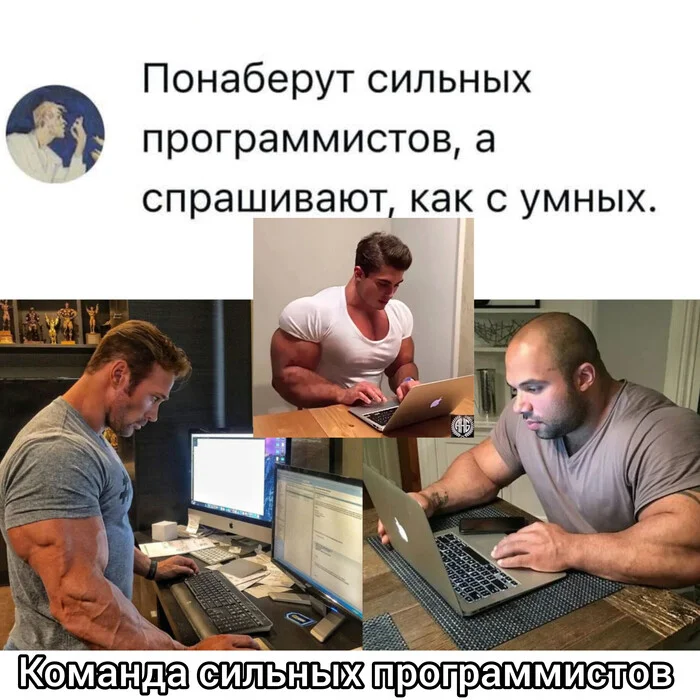

Попытка номер 3)))

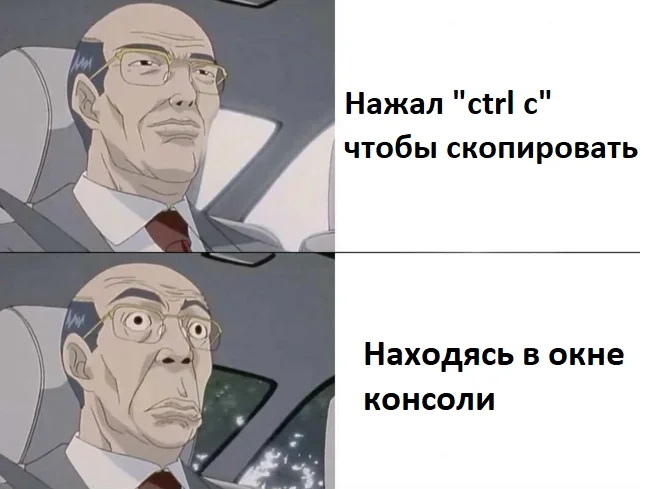